<a href="https://colab.research.google.com/github/martinieto12/YPD-DATA-SCIENCE-MARTINNIETO-2026/blob/main/Notebook_19_C15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

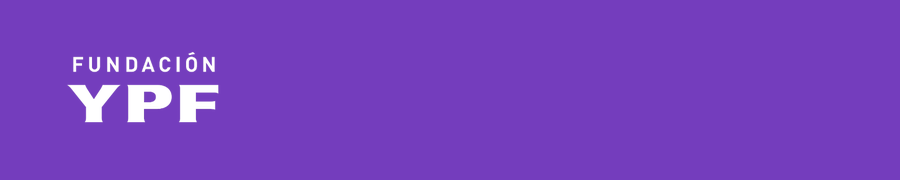


# Notebook 19: Evaluación y Métricas de Modelado Predictivo y Generativo

**Clase 15 — Módulo V**

Esta notebook corre en Google Colab y fuera de Colab sin modificar nada.

### Índice

- **Parte 0.** Repaso: carga y preparación de los datasets
- **Parte 1.** Métricas de Regresión (MAE, MSE, RMSE, R²)
- **Parte 2.** Métricas de Clasificación (matriz de confusión, Accuracy, Precisión, Recall, F1)
- **Parte 3.** Curva ROC y AUC
- **Parte 4.** Desafíos de evaluar respuestas no estructuradas (GenAI)
- **Parte 5.** Resumen comparativo de métricas
- **Parte 6.** Ejercicio para las salas de Zoom
- **Anexo.** Solución sugerida de la Parte 6


## Parte 0. Repaso: carga y preparación de los datasets

Usamos dos datasets que ya vienen del curso:

- **life_expectancy_data.csv** (desde la clase 8): para la parte de **regresión**.
- **cancer_mamario.csv** (desde la clase 12): para la parte de **clasificación**, con el mismo criterio de encoding que se usó en la Notebook 16.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_curve, auc
)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (6, 4)


In [2]:
# Carga de archivos: funciona en Colab (/content/) y en local, sin modificar nada
def cargar_csv(nombre):
    try:
        return pd.read_csv(f'/content/{nombre}')
    except FileNotFoundError:
        return pd.read_csv(nombre)

df_life = cargar_csv('life_expectancy_data.csv')
df_cancer = cargar_csv('cancer_mamario.csv')

print('life_expectancy_data:', df_life.shape)
print('cancer_mamario:', df_cancer.shape)


life_expectancy_data: (2938, 22)
cancer_mamario: (286, 10)


### Preparación para regresión (`life_expectancy_data.csv`)

Normalizamos los nombres de columnas (vienen con espacios de más, igual que en las notebooks anteriores) y nos quedamos con un subconjunto de variables predictoras sin faltantes, para no repetir el trabajo de limpieza completo que ya se hizo en la clase 8.


In [3]:
df_life.columns = df_life.columns.str.strip().str.replace(' ', '_')

features_reg = ['Adult_Mortality', 'Alcohol', 'BMI', 'GDP', 'Schooling', 'Income_composition_of_resources']
target_reg = 'Life_expectancy'

df_reg = df_life[features_reg + [target_reg]].dropna()

X_reg = df_reg[features_reg]
y_reg = df_reg[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# El scaler se ajusta SOLO con train, como venimos remarcando desde la clase 8
scaler = StandardScaler()
X_train_reg_sc = scaler.fit_transform(X_train_reg)
X_test_reg_sc = scaler.transform(X_test_reg)

print(f'Train: {X_train_reg.shape[0]} filas — Test: {X_test_reg.shape[0]} filas')


Train: 1848 filas — Test: 463 filas


### Preparación para clasificación (`cancer_mamario.csv`)

Mismo dataset y mismo criterio de encoding que la Notebook 16: es un dataset enteramente categórico (salvo `deg-malig`), así que usamos `get_dummies` sobre las variables categóricas. El target es `class`: lo convertimos a binario (1 = hubo recurrencia, 0 = no hubo).


In [4]:
df_cancer = df_cancer.dropna()
df_cancer['target'] = (df_cancer['class'] == 'recurrence-events').astype(int)

cat_cols = ['age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'breast', 'breast-quad', 'irradiat']
df_cancer_enc = pd.get_dummies(df_cancer, columns=cat_cols, drop_first=True)

X_clf = df_cancer_enc.drop(columns=['class', 'target'])
y_clf = df_cancer_enc['target']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

print(f'Train: {X_train_clf.shape[0]} filas — Test: {X_test_clf.shape[0]} filas')
print('Proporción de recurrencia en test:', round(y_test_clf.mean(), 2))


Train: 214 filas — Test: 72 filas
Proporción de recurrencia en test: 0.29


## Parte 1. Métricas de Regresión

Entrenamos una regresión lineal para predecir `Life_expectancy` y calculamos MAE, MSE, RMSE y R² **a mano** (con la fórmula) y después los confirmamos con `sklearn.metrics`, para que quede claro qué está calculando cada una.


In [5]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg_sc, y_train_reg)

y_pred_reg = modelo_reg.predict(X_test_reg_sc)
y_test_arr = y_test_reg.to_numpy()

# --- Cálculo manual ---
mae_manual = np.mean(np.abs(y_test_arr - y_pred_reg))
mse_manual = np.mean((y_test_arr - y_pred_reg) ** 2)
rmse_manual = np.sqrt(mse_manual)

# --- Con sklearn ---
mae_sklearn = mean_absolute_error(y_test_reg, y_pred_reg)
mse_sklearn = mean_squared_error(y_test_reg, y_pred_reg)
rmse_sklearn = np.sqrt(mse_sklearn)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f'MAE  — manual: {mae_manual:.3f} | sklearn: {mae_sklearn:.3f}')
print(f'MSE  — manual: {mse_manual:.3f} | sklearn: {mse_sklearn:.3f}')
print(f'RMSE — manual: {rmse_manual:.3f} | sklearn: {rmse_sklearn:.3f}')
print(f'R²   — sklearn: {r2:.3f}')


MAE  — manual: 3.364 | sklearn: 3.364
MSE  — manual: 24.133 | sklearn: 24.133
RMSE — manual: 4.913 | sklearn: 4.913
R²   — sklearn: 0.760


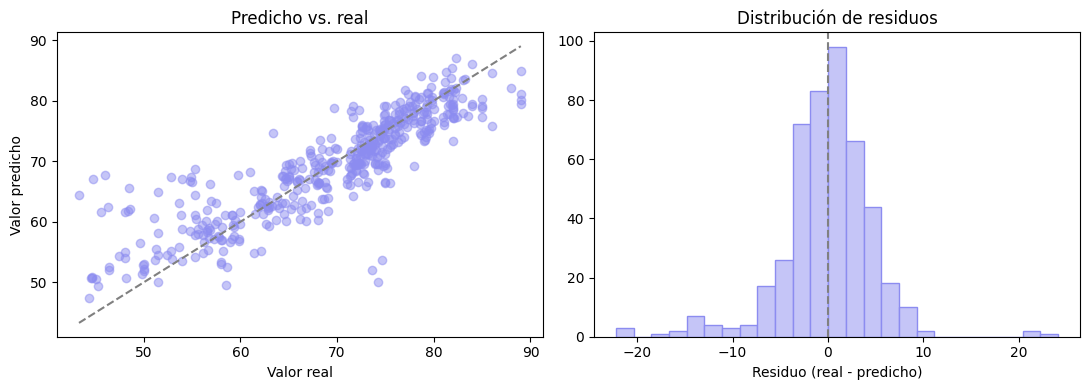

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.5, color='#8c8cf0')
lims = [y_test_reg.min(), y_test_reg.max()]
axes[0].plot(lims, lims, linestyle='--', color='gray')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Predicho vs. real')

residuos = y_test_arr - y_pred_reg
axes[1].hist(residuos, bins=25, color='#c5c5f7', edgecolor='#8c8cf0')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Residuo (real - predicho)')
axes[1].set_title('Distribución de residuos')

plt.tight_layout()
plt.show()


**Cuándo usar cada una:**

- **MAE**: error promedio en la misma unidad que la variable (años de expectativa de vida, en este caso). Fácil de explicar.
- **MSE**: penaliza más los errores grandes al elevarlos al cuadrado, pero pierde la unidad original.
- **RMSE**: vuelve a la unidad original, sigue penalizando los errores grandes más que el MAE. Es sensible a outliers.
- **R²**: qué proporción de la varianza de la variable objetivo explica el modelo. No tiene unidad, sirve para comparar modelos entre sí.


## Parte 2. Métricas de Clasificación

Entrenamos una regresión logística sobre `cancer_mamario` y calculamos la matriz de confusión, Accuracy, Precisión, Recall y F1-score.


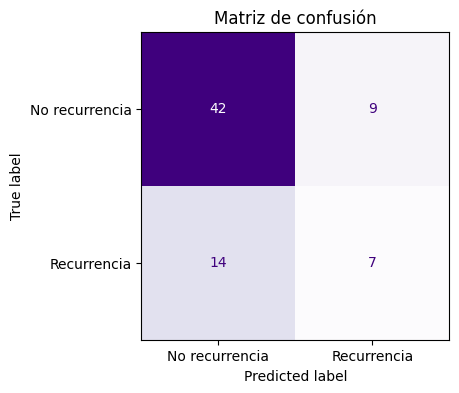

In [7]:
modelo_clf = LogisticRegression(max_iter=1000)
modelo_clf.fit(X_train_clf, y_train_clf)

y_pred_clf = modelo_clf.predict(X_test_clf)

cm = confusion_matrix(y_test_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No recurrencia', 'Recurrencia'])
disp.plot(cmap='Purples', colorbar=False)
plt.title('Matriz de confusión')
plt.show()


In [8]:
acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf, zero_division=0)
rec = recall_score(y_test_clf, y_pred_clf, zero_division=0)
f1 = f1_score(y_test_clf, y_pred_clf, zero_division=0)

print(f'Accuracy:  {acc:.3f}')
print(f'Precisión: {prec:.3f}')
print(f'Recall:    {rec:.3f}')
print(f'F1-score:  {f1:.3f}')
print()
print(classification_report(y_test_clf, y_pred_clf, target_names=['No recurrencia', 'Recurrencia'], zero_division=0))


Accuracy:  0.681
Precisión: 0.438
Recall:    0.333
F1-score:  0.378

                precision    recall  f1-score   support

No recurrencia       0.75      0.82      0.79        51
   Recurrencia       0.44      0.33      0.38        21

      accuracy                           0.68        72
     macro avg       0.59      0.58      0.58        72
  weighted avg       0.66      0.68      0.67        72



**Recordatorio de la clase:** este es justamente el dataset chico y difícil que venimos usando desde la clase 12. Si el resultado no es espectacular, no es un error de código: es una señal de que las variables disponibles tienen poder predictivo limitado.

Y el punto central de hoy: **la métrica que conviene mirar depende del costo de cada error.** Si el falso negativo es el error caro (por ejemplo, un diagnóstico que se escapa), priorizamos Recall. Si el falso positivo es el que más cuesta, priorizamos Precisión.


## Parte 3. Curva ROC y AUC

La curva ROC grafica la Tasa de Verdaderos Positivos (Recall) contra la Tasa de Falsos Positivos, recorriendo distintos umbrales de decisión (no solo el 0,5 por defecto). El AUC resume esa curva en un solo número.


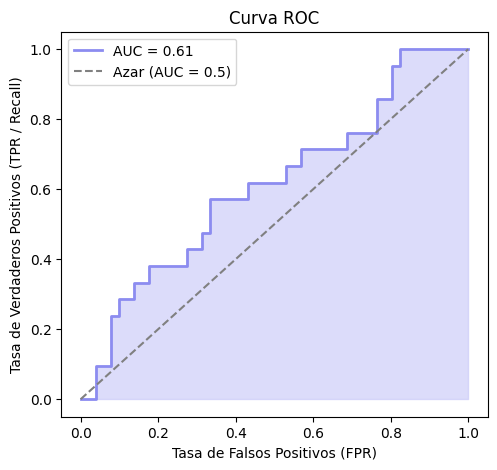

AUC: 0.612


In [9]:
y_proba_clf = modelo_clf.predict_proba(X_test_clf)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba_clf)
auc_value = auc(fpr, tpr)

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, color='#8c8cf0', linewidth=2, label=f'AUC = {auc_value:.2f}')
plt.fill_between(fpr, tpr, 0, color='#c5c5f7', alpha=0.6)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

print(f'AUC: {auc_value:.3f}')


Un AUC de 1 es un clasificador perfecto; un AUC de 0,5 equivale a tirar una moneda. A diferencia de la Accuracy, el AUC no depende de un único umbral de corte, así que es más informativo cuando las clases están desbalanceadas.


## Parte 4. Desafíos de evaluar respuestas no estructuradas (GenAI)

Todo lo anterior funciona porque hay una **única respuesta correcta** contra la cual comparar: un número, o una clase. Un modelo generativo (un LLM, por ejemplo) no tiene eso: la salida es texto abierto, y puede haber muchas formas correctas de decir lo mismo — y formas incorrectas que **usan casi las mismas palabras** que la referencia.

El siguiente ejemplo ilustra el problema con una consigna simple: le pedimos a dos respuestas candidatas que expliquen qué hace una regresión lineal, y las comparamos contra una respuesta de referencia con dos métricas basadas en superposición de texto.


In [10]:
referencia = "El modelo de regresión lineal predice un valor numérico continuo a partir de las variables de entrada."
respuesta_a = "La regresión lineal estima una salida numérica continua usando las variables de entrada."
respuesta_b = "El modelo de regresión lineal predice categorías discretas usando las variables de entrada."

print('Referencia:  ', referencia)
print('Respuesta A: ', respuesta_a, '  (correcta, dicha con otras palabras)')
print('Respuesta B: ', respuesta_b, '  (incorrecta: describe clasificación, no regresión)')


Referencia:   El modelo de regresión lineal predice un valor numérico continuo a partir de las variables de entrada.
Respuesta A:  La regresión lineal estima una salida numérica continua usando las variables de entrada.   (correcta, dicha con otras palabras)
Respuesta B:  El modelo de regresión lineal predice categorías discretas usando las variables de entrada.   (incorrecta: describe clasificación, no regresión)


In [11]:
def overlap_palabras(ref, resp):
    ref_tokens = set(ref.lower().split())
    resp_tokens = set(resp.lower().split())
    return len(ref_tokens & resp_tokens) / len(ref_tokens)

overlap_a = overlap_palabras(referencia, respuesta_a)
overlap_b = overlap_palabras(referencia, respuesta_b)

print('Superposición de palabras con la referencia (proxy simple de ROUGE):')
print(f'  Respuesta A (correcta):   {overlap_a:.2f}')
print(f'  Respuesta B (incorrecta): {overlap_b:.2f}')


Superposición de palabras con la referencia (proxy simple de ROUGE):
  Respuesta A (correcta):   0.40
  Respuesta B (incorrecta): 0.60


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer()
vectores = vectorizer.fit_transform([referencia, respuesta_a, respuesta_b])

sim_a = cosine_similarity(vectores[0], vectores[1])[0][0]
sim_b = cosine_similarity(vectores[0], vectores[2])[0][0]

print('Similitud coseno con TF-IDF:')
print(f'  Respuesta A (correcta):   {sim_a:.2f}')
print(f'  Respuesta B (incorrecta): {sim_b:.2f}')


Similitud coseno con TF-IDF:
  Respuesta A (correcta):   0.28
  Respuesta B (incorrecta): 0.60


**¿Qué muestra este resultado?** La Respuesta B — que está mal, porque describe clasificación en lugar de regresión — comparte más palabras literales con la referencia que la Respuesta A, que es correcta pero está dicha con sinónimos. Una métrica de superposición de texto puede terminar puntuando mejor a la respuesta incorrecta.

Esto es exactamente lo que separa a las métricas estadísticas clásicas de una evaluación por **coherencia semántica**: medir si las palabras coinciden no es lo mismo que medir si el significado es correcto.

**Enfoques que se usan en la práctica** (no los corremos acá porque requieren un modelo de lenguaje):

- **Métricas automáticas heredadas de NLP** (BLEU, ROUGE, perplexity): rápidas y baratas, pero miden superposición de superficie, como se acaba de ver.
- **Evaluación humana**: la más confiable, pero costosa y lenta de escalar.
- **LLM as a judge**: un modelo de lenguaje evalúa la respuesta de otro según una consigna o rúbrica definida — un punto intermedio entre automatizar y capturar significado.

Y los riesgos a vigilar en cualquiera de estos enfoques: **alucinaciones** (el modelo inventa información no sustentada), **pérdida de coherencia** en respuestas largas, y **relevancia** (una respuesta puede ser correcta y aun así no responder lo que se preguntó).


## Parte 5. Resumen comparativo de métricas

Todo lo calculado hoy, en una sola tabla.


In [13]:
resumen = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²', 'Accuracy', 'Precisión', 'Recall', 'F1-score', 'AUC'],
    'Tipo de problema': ['Regresión', 'Regresión', 'Regresión',
                          'Clasificación', 'Clasificación', 'Clasificación', 'Clasificación', 'Clasificación'],
    'Valor': [mae_sklearn, rmse_sklearn, r2, acc, prec, rec, f1, auc_value]
})
resumen['Valor'] = resumen['Valor'].round(3)
resumen


,Métrica,Tipo de problema,Valor
0,MAE,Regresión,3.364
1,RMSE,Regresión,4.913
2,R²,Regresión,0.760
3,Accuracy,Clasificación,0.681
4,Precisión,Clasificación,0.438
5,Recall,Clasificación,0.333
6,F1-score,Clasificación,0.378
7,AUC,Clasificación,0.612


## Parte 6. Ejercicio para las salas de Zoom

**Dataset:** `venta_autos.csv` — predicción de `price`.

Para que se concentren en las métricas de evaluación (el tema de hoy) y no en la limpieza de datos (el tema de la clase 13), la siguiente celda ya deja el dataset filtrado y listo. Solo tienen que correrla.


In [14]:
df_autos = cargar_csv('venta_autos.csv')

# Limpieza básica ya resuelta, para poder enfocarnos en las métricas
df_autos_clean = df_autos[
    (df_autos['price'] > 100) & (df_autos['price'] < 60000) &
    (df_autos['yearOfRegistration'] >= 1990) & (df_autos['yearOfRegistration'] <= 2016) &
    (df_autos['powerPS'] > 0) & (df_autos['powerPS'] < 500)
].copy()

df_autos_clean = df_autos_clean.dropna(subset=['vehicleType', 'gearbox', 'model', 'fuelType', 'brand'])

features_autos = ['yearOfRegistration', 'powerPS', 'kilometer']
X_autos = df_autos_clean[features_autos]
y_autos = df_autos_clean['price']

X_train_autos, X_test_autos, y_train_autos, y_test_autos = train_test_split(
    X_autos, y_autos, test_size=0.2, random_state=42
)

print(f'Dataset listo: {df_autos_clean.shape[0]} filas, {X_train_autos.shape[0]} en train')


Dataset listo: 18138 filas, 14510 en train


### Consigna (40 minutos)

1. **(10 min)** Entrenen un modelo de regresión lineal para predecir `price` a partir de `X_train_autos`.
2. **(10 min)** Calculen el MAE, el RMSE y el R² del modelo sobre el conjunto de test.
3. **(10 min)** Entrenen un `DummyRegressor` (piso de referencia) y calculen las mismas tres métricas.
4. **(10 min)** Comparen: ¿el modelo superó al piso? ¿Cuál de las tres métricas les resultó más fácil de interpretar en euros, y por qué?


**Paso 1** — Entrenen el modelo de regresión lineal.

In [17]:
# Escriban acá su código para el Paso 1
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_autos, y_train_autos)



LinearRegression()

**Paso 2** — Calculen MAE, RMSE y R² sobre el test.

In [16]:
# Escriban acá su código para el Paso 2
modelos_regresion = {
    'Regresion Lineal': modelo_lineal}

resultados_regresion = []

for nombre, modelo in modelos_regresion.items():
    predicciones = modelo.predict(X_test_autos)
    mae = mean_absolute_error(y_test_autos, predicciones)
    rmse = mean_squared_error(y_test_autos, predicciones) ** 0.5
    r2 = r2_score(y_test_autos, predicciones)
    resultados_regresion.append({'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

df_resultados_regresion = pd.DataFrame(resultados_regresion)
df_resultados_regresion

,Modelo,MAE,RMSE,R2
0,Regresion Lineal,2730.24823,4071.70968,0.691848


**Paso 3** — Entrenen el DummyRegressor y calculen las mismas métricas.

In [24]:
# Escriban acá su código para el Paso 3
# Piso de referencia para regresión
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_train_autos, y_train_autos)
y_pred_dummy = dummy_reg.predict(X_test_autos)

mae_dummy = mean_absolute_error(y_test_autos, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test_autos, y_pred_dummy))
r2_dummy = r2_score(y_test_autos, y_pred_dummy)
print(f"Piso de referencia (predecir la media):")
print(f"  MAE: {mae_dummy:.2f} euros")
print(f"  RMSE: {rmse_dummy:.2f} euros")
print(f"  R²:  {r2_dummy:.4f}")


Piso de referencia (predecir la media):
  MAE: 5121.58 euros
  RMSE: 7335.05 euros
  R²:  -0.0000


**Paso 4** — Comparen los resultados y anoten sus conclusiones en una celda de texto.

In [ ]:
# Escriban acá su código para el Paso 4


### Pistas

- `DummyRegressor(strategy='mean')` predice siempre el promedio de `y_train`, sin mirar las variables. Es el piso mínimo que cualquier modelo real debería superar.
- El escalado no es obligatorio para una regresión lineal simple con pocas variables, pero no está de más si después quieren comparar con otros modelos.
- El RMSE está en la misma unidad que `price` (euros): eso lo hace más fácil de comunicar que el MSE.

### Errores frecuentes a evitar

- Ajustar el `DummyRegressor` con `y_test` en lugar de `y_train` — el piso de referencia también se entrena solo con train.
- Comparar el R² del modelo real solamente contra 0. El punto de comparación es el **piso de referencia**, no un número abstracto.
- Sacar conclusiones de una sola métrica. MAE, RMSE y R² cuentan historias distintas — RMSE, por ejemplo, va a ser más alto que el MAE si hay autos con errores de predicción grandes.


## Anexo. Solución sugerida de la Parte 6

Si van a repartir esta notebook sin soluciones, borren esta última sección.


In [18]:
# Paso 1: modelo de regresión lineal
modelo_autos = LinearRegression()
modelo_autos.fit(X_train_autos, y_train_autos)
y_pred_autos = modelo_autos.predict(X_test_autos)


In [19]:
# Paso 2: métricas del modelo
mae_autos = mean_absolute_error(y_test_autos, y_pred_autos)
rmse_autos = np.sqrt(mean_squared_error(y_test_autos, y_pred_autos))
r2_autos = r2_score(y_test_autos, y_pred_autos)

print(f'Modelo — MAE: {mae_autos:.0f} € | RMSE: {rmse_autos:.0f} € | R²: {r2_autos:.3f}')


Modelo — MAE: 2730 € | RMSE: 4072 € | R²: 0.692


In [20]:
# Paso 3: piso de referencia
piso = DummyRegressor(strategy='mean')
piso.fit(X_train_autos, y_train_autos)
y_pred_piso = piso.predict(X_test_autos)

mae_piso = mean_absolute_error(y_test_autos, y_pred_piso)
rmse_piso = np.sqrt(mean_squared_error(y_test_autos, y_pred_piso))
r2_piso = r2_score(y_test_autos, y_pred_piso)

print(f'Piso   — MAE: {mae_piso:.0f} € | RMSE: {rmse_piso:.0f} € | R²: {r2_piso:.3f}')


Piso   — MAE: 5122 € | RMSE: 7335 € | R²: -0.000


**Paso 4 — observación:** el modelo real debería mostrar un MAE y un RMSE bastante menores que el piso, y un R² muy por encima de 0 (el piso, por definición, tiene R² cercano a 0 sobre su propio test). El RMSE del modelo es el número más fácil de comunicar: está en euros, y dice en promedio cuánto se equivoca el modelo al predecir el precio de un auto — con más peso sobre los errores grandes que el MAE.
